In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Load RFM data
rfm = pd.read_csv('rfm_data.csv')

In [11]:
# Check if loaded correctly
print(rfm.shape)
print(rfm.head())
print(rfm.isnull().sum())
print(f"\nRecency range: {rfm['recency_days'].min()} to {rfm['recency_days'].max()} days")

(93357, 4)
                 customer_unique_id  recency_days  frequency  monetary
0  0a0a92112bd4c708ca5fde585afaa872           334          1  13664.08
1  da122df9eeddfedc1dc1f5349a1a690c           515          2   7571.63
2  763c8b1c9c68a0229c42c9fc6f662b93            45          1   7274.88
3  dc4802a71eae9be1dd28f5d788ceb526           563          1   6929.31
4  459bef486812aa25204be022145caa62            35          1   6922.21
customer_unique_id    0
recency_days          0
frequency             0
monetary              0
dtype: int64

Recency range: 0 to 695 days


In [12]:
# Score each metric 1-5
rfm['R_score'] = pd.qcut(rfm['recency_days'], 5, 
                          labels=[5,4,3,2,1])

rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, 
                          labels=[1,2,3,4,5])

rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, 
                          labels=[1,2,3,4,5])

# Combined RFM score
rfm['RFM_score'] = (rfm['R_score'].astype(str) + 
                    rfm['F_score'].astype(str) + 
                    rfm['M_score'].astype(str))

print(rfm[['customer_unique_id','recency_days',
           'frequency','monetary',
           'R_score','F_score','M_score']].head(10))

                 customer_unique_id  recency_days  frequency  monetary  \
0  0a0a92112bd4c708ca5fde585afaa872           334          1  13664.08   
1  da122df9eeddfedc1dc1f5349a1a690c           515          2   7571.63   
2  763c8b1c9c68a0229c42c9fc6f662b93            45          1   7274.88   
3  dc4802a71eae9be1dd28f5d788ceb526           563          1   6929.31   
4  459bef486812aa25204be022145caa62            35          1   6922.21   
5  ff4159b92c40ebe40454e3e6a7c35ed6           462          1   6726.66   
6  4007669dec559734d6f53e029e360987           278          1   6081.54   
7  eebb5dda148d3893cdaf5b5ca3040ccb           498          1   4764.34   
8  48e1ac109decbb87765a3eade6854098            68          1   4681.78   
9  c8460e4251689ba205045f3ea17884a1            21          4   4655.91   

  R_score F_score M_score  
0       2       1       5  
1       1       5       5  
2       5       1       5  
3       1       1       5  
4       5       1       5  
5       1       1

In [13]:
# Assign Segments
def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])
    
    if r >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and m >= 4:
        return 'Loyal Customers'
    elif r >= 4 and m <= 3:
        return 'Recent Customers'
    elif r >= 3 and m >= 3:
        return 'Potential Loyalists'
    elif r <= 2 and m >= 4:
        return 'High Value At Risk'
    elif r <= 2 and m >= 3:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['segment'] = rfm.apply(segment_customer, axis=1)

# Check if it makes sense now
print(rfm.groupby('segment')[['recency_days',
    'frequency','monetary']].mean().round(2))
print("\nSegment counts:")
print(rfm['segment'].value_counts())

                     recency_days  frequency  monetary
segment                                               
At Risk                    394.74       1.02    108.90
Champions                   91.29       1.08    306.63
High Value At Risk         393.60       1.06    310.48
Lost Customers             338.15       1.00     55.35
Loyal Customers            220.66       1.07    284.11
Potential Loyalists        221.83       1.02    108.22
Recent Customers            89.77       1.01     73.17

Segment counts:
segment
Lost Customers         22884
Recent Customers       22063
Champions              15496
High Value At Risk     14417
Loyal Customers         7430
At Risk                 7329
Potential Loyalists     3738
Name: count, dtype: int64


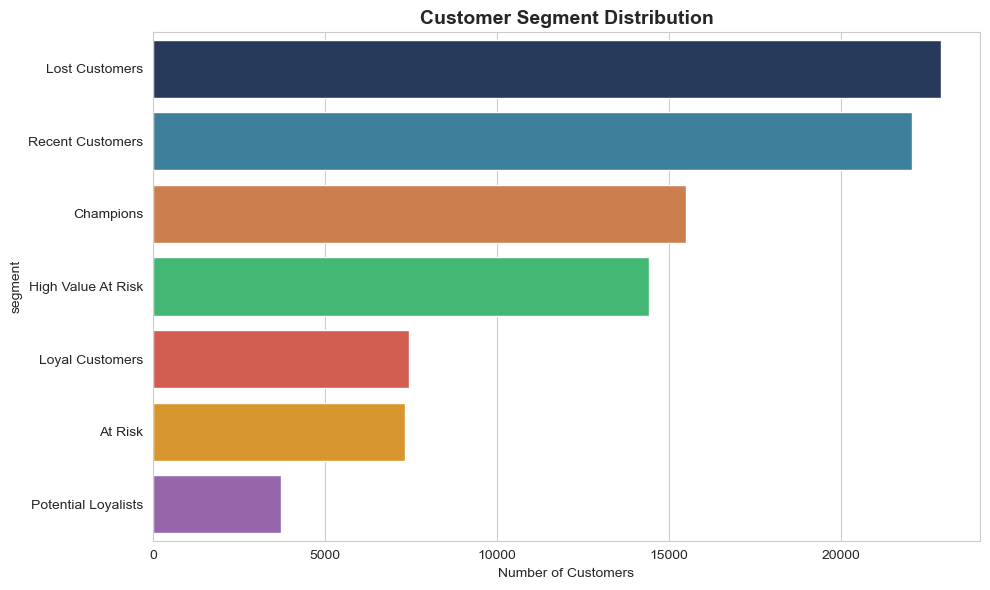

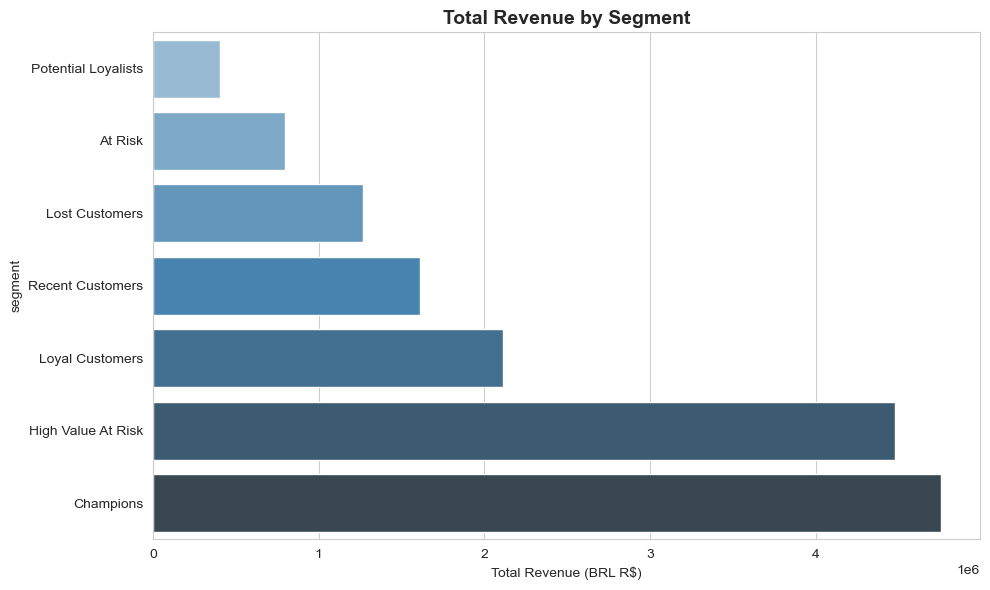

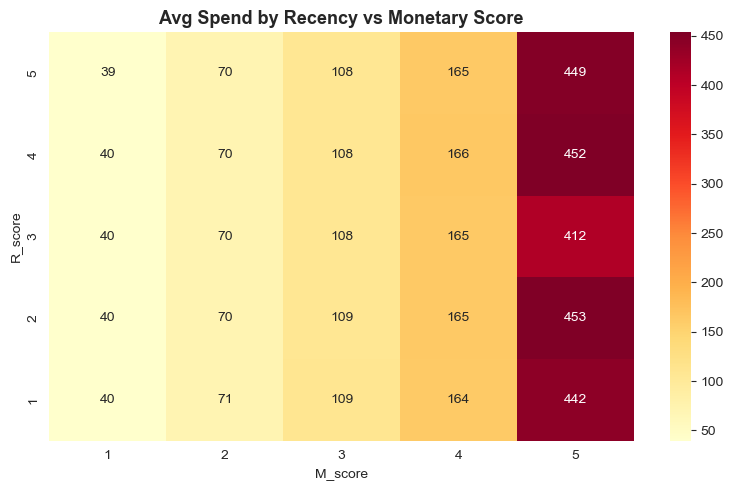

In [14]:
# Chart 1 — Segment Distribution
plt.figure(figsize=(10,6))
segment_counts = rfm['segment'].value_counts()
colors = ['#1F3864','#2E86AB','#E07B39',
          '#2ecc71','#e74c3c','#f39c12','#9b59b6']
sns.barplot(x=segment_counts.values, 
            y=segment_counts.index, palette=colors)
plt.title('Customer Segment Distribution', 
          fontsize=14, fontweight='bold')
plt.xlabel('Number of Customers')
plt.tight_layout()
plt.savefig('segment_counts.png', dpi=150)
plt.show()

# Chart 2 — Revenue by Segment (should make sense now)
plt.figure(figsize=(10,6))
segment_rev = rfm.groupby('segment')['monetary'].sum().sort_values()
sns.barplot(x=segment_rev.values, 
            y=segment_rev.index, palette='Blues_d')
plt.title('Total Revenue by Segment', 
          fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (BRL R$)')
plt.tight_layout()
plt.savefig('segment_revenue.png', dpi=150)
plt.show()

# Chart 3 — Heatmap
plt.figure(figsize=(8,5))
rfm_pivot = rfm.groupby(
    ['R_score','M_score'])['monetary'].mean().unstack()
sns.heatmap(rfm_pivot, cmap='YlOrRd', 
            annot=True, fmt='.0f')
plt.title('Avg Spend by Recency vs Monetary Score', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rfm_heatmap.png', dpi=150)
plt.show()

In [15]:
# Segment summary
segment_summary = rfm.groupby('segment').agg(
    customer_count=('customer_unique_id','count'),
    avg_recency=('recency_days','mean'),
    avg_frequency=('frequency','mean'),
    avg_monetary=('monetary','mean'),
    total_revenue=('monetary','sum')
).round(2).reset_index()

print(segment_summary)

# Export CSV
rfm.to_csv('rfm_segments_final.csv', index=False)
segment_summary.to_csv('segment_summary.csv', index=False)
print("\n✅ Files exported!")

               segment  customer_count  avg_recency  avg_frequency  \
0              At Risk            7329       394.74           1.02   
1            Champions           15496        91.29           1.08   
2   High Value At Risk           14417       393.60           1.06   
3       Lost Customers           22884       338.15           1.00   
4      Loyal Customers            7430       220.66           1.07   
5  Potential Loyalists            3738       221.83           1.02   
6     Recent Customers           22063        89.77           1.01   

   avg_monetary  total_revenue  
0        108.90      798116.48  
1        306.63     4751557.54  
2        310.48     4476163.25  
3         55.35     1266710.68  
4        284.11     2110962.19  
5        108.22      404544.39  
6         73.17     1614407.24  

✅ Files exported!
